In [ ]:
#   Copyright 2022 - 2026 The PyMC Labs Developers
#
#   Licensed under the Apache License, Version 2.0 (the "License");
#   you may not use this file except in compliance with the License.
#   You may obtain a copy of the License at
#
#       http://www.apache.org/licenses/LICENSE-2.0
#
#   Unless required by applicable law or agreed to in writing, software
#   distributed under the License is distributed on an "AS IS" BASIS,
#   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#   See the License for the specific language governing permissions and
#   limitations under the License.
"""Halo effects in multi-dimensional media mix models (experiment notebook)."""
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.16.7
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---

(mmm_halo)=
# Halo Effects in Multi-Dimensional Media Mix Models

## Motivation

In brand portfolios, whether in automotive, consumer electronics, fashion, or any industry with multiple products under one umbrella, a **flagship product's** advertising often lifts awareness and consideration for the entire portfolio. This cross-product spillover is called the **halo effect**.

Consider a company with three products in its portfolio:

| Product | Role |
|---------|------|
| Product A | Flagship awareness driver (highest ad spend, most recognisable) |
| Product B | Mid-range offering, benefits from brand consideration |
| Product C | Complementary product, benefits from brand consideration |

When the company runs a major TV campaign for Product A, three things happen:

1. **Direct effect** — Product A sales increase.
2. **Brand halo** — The campaign lifts overall brand awareness, driving consideration for *all* products.
3. **Product halo** — Interest in Product A drives cross-shopping to Products B and C.

A standard Media Mix Model (MMM) captures (1) but completely misses (2) and (3), leading to **biased ROAS** (non-flagship products get credit for halo-driven sales) and **misallocated budgets** (the flagship is under-valued).

In this notebook we explore various approaches to modelling halo effects in marketing mix models. We work with synthetic data with a known halo structure, and fit multiple models: a baseline MMM with no halo and several halo-aware variants in order to compare parameter recovery and model fit.

## Business Implications

Ignoring halo effects in an MMM leads to concrete business problems:

- **Biased ROAS estimates.** The flagship product appears to have *lower* ROAS than it truly does, because part of its media uplift materialises as sales of other products. Those other products, in turn, appear to have *higher* ROAS because their intercepts absorb the halo-driven sales they did not earn themselves.

- **Budget misallocation.** If the flagship's true portfolio-wide ROI is under-estimated, optimisation routines will systematically under-invest in the flagship and over-invest in non-flagship products whose apparent performance is inflated.

- **Portfolio strategy.** The total value of a flagship campaign is its direct effect *plus* the halo-driven sales across the portfolio. Quantifying this total informs strategic decisions such as whether to increase the flagship's media budget, launch a new flagship candidate, or reallocate spend from non-flagship products whose standalone ROAS does not justify their budgets once halo is accounted for.


## The Standard Multi-Dimensional MMM

The `MMM` class in `pymc_marketing.mmm.multidimensional` with `dims=("product",)` estimates:

$$
y_{t,i} = \alpha_i
  + \sum_{m=1}^{M} \beta_{m,i}\, f_m\!\bigl(\{x_{m,s,i}\}_{s \le t}\bigr)
  + \sum_{c} \gamma_{c,i}\, z_{c,t,i}
  + \varepsilon_{t,i}
$$

where $f_m$ chains an adstock transformation (geometric decay) with a saturation transformation (logistic).  Crucially, the channel contribution for product $i$ depends **only** on product $i$'s own media spend, there is no cross-product coupling.

## Approaches to Modeling Halo Effects

In this section we describe four progressively more structured approaches for modelling halo effects.

We denote the total media contribution for product $j$ at time $t$ as:

$$
C_{t,j} = \sum_{m=1}^{M} \beta_{m,j}\, f_m\!\bigl(\{x_{m,s,j}\}_{s \le t}\bigr)
$$

Before introducing structured halo models, two simpler workarounds are worth mentioning:

**(a) Include all cross-product channels directly.**  For each product $i$, add every other product's individual channel spend columns as additional media or control inputs. This explodes the number of parameters ($P \times M$ channels instead of $M$), making identification difficult with many products or channels and leading to severe collinearity.

**(b) Aggregate cross-product spend as a control.**  For each product $i$, compute the total media spend from all *other* products and include it as a single control variable. This approach is much simpler and is the basis of **Approach 0** below.

We now describe four progressively more structured approaches.

### Approach 0 — Other Products' Total Media as a Channel

The simplest proxy: for each product $i$, sum the raw media spend of **all other products** and include that aggregate as an additional channel column. The `MMM` class then applies its own adstock and saturation to this ``other_products_total_media`` channel, giving it a product-specific decay rate and diminishing-returns curve.

- 0 extra parameters beyond the standard channel machinery.
- No structural halo term; the model learns a single transformed
  cross-product signal per product.
- Cannot distinguish *which* other product drives the spillover.

### Approach 1 — Spillover Matrix

Introduce a matrix $H \in \mathbb{R}^{P \times P}$, where $P$ is the number of products in the portfolio, capturing cross-product spillover:

$$
y_{t,i} = \alpha_i + C_{t,i}
  + \sum_{j=1}^{P} H_{ij}\, C_{t,j}
  + \varepsilon_{t,i}
$$

- $P^2$ halo parameters.
- Most flexible: can model arbitrary product-to-product effects.
- Hardest to identify with limited data.
- Priors: $H_{ij} \sim \text{HalfNormal}(\sigma)$ (positive spillover only).

### Approach 2 — Latent Brand Awareness Factor

Assume a single latent *brand awareness* signal driven by all products' media:

$$
A_t = \sum_{j=1}^{P} w_j\, C_{t,j}
\qquad\text{then}\qquad
y_{t,i} = \alpha_i + C_{t,i} + \lambda_i\, A_t + \varepsilon_{t,i}
$$

- $2P$ parameters ($w_j$ weights + $\lambda_i$ sensitivities).
- Rank-1 approximation of the spillover matrix: $H_{ij} \approx \lambda_i\, w_j$.
- Interpretable: "the flagship drives 60 % of brand awareness".
- Cannot model product-specific halo patterns beyond the shared factor.

### Approach 3 — Flagship-Specific Halo

When the awareness driver is known *a priori* (here, Product A):

$$
y_{t,i} = \alpha_i + C_{t,i}
  + \delta_i\, C_{t,\text{flagship}}
  + \varepsilon_{t,i}
$$

with $\delta_{\text{flagship}} = 0$ to avoid double-counting.

- $P - 1$ halo parameters.
- Simplest; directly answers "how much does flagship advertising lift other
  products' sales?"
- Requires knowing which product is the awareness driver.

## Simulation Design

In order to make these approaches more tangible, we generate synthetic data from a DGP with halo components and study the performance of each approach.

1. **Synthetic data** — We generate observations from a DGP that matches Approach 3 (flagship halo from Product A), using PyMC's `do()` + `sample_prior_predictive()` pattern.
2. **Baseline** — Fit the standard `MMM` class (no halo).
3. **Approach 0** — Fit the `MMM` class with aggregate cross-product spend as an additional channel (adstock + saturation applied).
4. **Approach 1** — Fit the `MMM` class with a `SpilloverMatrixEffect` a `MuEffect`.
5. **Approach 2** — Fit the `MMM` class with a `BrandAwarenessEffect` a `MuEffect`.
6. **Approach 3** — Fit the `MMM` class with a `FlagshipHaloEffect` a `MuEffect`.
   (the "correct" model matching the DGP).
7. **Comparison** — Compare parameter recovery and posterior predictive fit.

## Prepare Notenbook


In [30]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
from pymc import do

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.additive_effect import MuEffect
from pymc_marketing.mmm.multidimensional import MMM
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

In [ ]:
seed: int = sum(map(ord, "halo"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

### Simulation Parameters

In [ ]:
PRODUCTS: list[str] = ["product_a", "product_b", "product_c"]
CHANNELS: list[str] = ["tv", "digital"]
FLAGSHIP_IDX: int = 0  # product_a is the flagship awareness driver

N_DATES: int = 110
L_MAX: int = 8
DATE_RANGE = pd.date_range(start="2022-01-03", freq="W-MON", periods=N_DATES)

SAMPLER_CONFIG: dict = {
    "nuts_sampler": "nutpie",
    "chains": 4,
    "draws": 1_000,
    "tune": 1_000,
    "random_seed": rng,
}

N_PRODUCTS = len(PRODUCTS)
N_CHANNELS = len(CHANNELS)

## Synthetic Data Generation

We follow the `do()` + `sample_prior_predictive()` pattern from the notebook {ref}`mmm_data_generator`.

**Steps**:
1. Generate channel spend covariates per product.
2. Draw ground-truth parameter values from prior distributions via `pm.draw()`.
3. Build a custom PyMC model for the DGP that includes the halo structure, using
   the same `geometric_adstock` and `logistic_saturation` functions from
   `pymc_marketing.mmm.transformers`.
4. Clamp parameters to ground truth via `pymc.do()`.
5. Forward-sample with `pm.sample_prior_predictive(draws=1)`.

### 2.1 Generate Channel Spend Data

In [31]:
spend_scales = {
    "product_a": {"tv": 3.0, "digital": 2.0},
    "product_b": {"tv": 1.5, "digital": 1.8},
    "product_c": {"tv": 1.0, "digital": 1.5},
}

rows = []
for product in PRODUCTS:
    for _t, date in enumerate(DATE_RANGE):
        row = {"date": date, "product": product}
        for channel in CHANNELS:
            row[channel] = rng.exponential(scale=spend_scales[product][channel])
        rows.append(row)

spend_df = pd.DataFrame(rows)
spend_df["y_dummy"] = 1.0

spend_df.head(9)

,date,product,tv,digital,y_dummy
0,2022-01-03,product_a,1.619009,0.216920,1.0
1,2022-01-10,product_a,5.473168,0.254221,1.0
2,2022-01-17,product_a,7.804768,0.001579,1.0
3,2022-01-24,product_a,2.855626,7.069826,1.0
4,2022-01-31,product_a,1.324497,3.994964,1.0
5,2022-02-07,product_a,4.266636,10.652296,1.0
6,2022-02-14,product_a,8.149174,0.476517,1.0
7,2022-02-21,product_a,2.335130,1.272283,1.0
8,2022-02-28,product_a,1.839607,3.169540,1.0


Text(0.5, 1.02, 'Generated Channel Spend by Product')

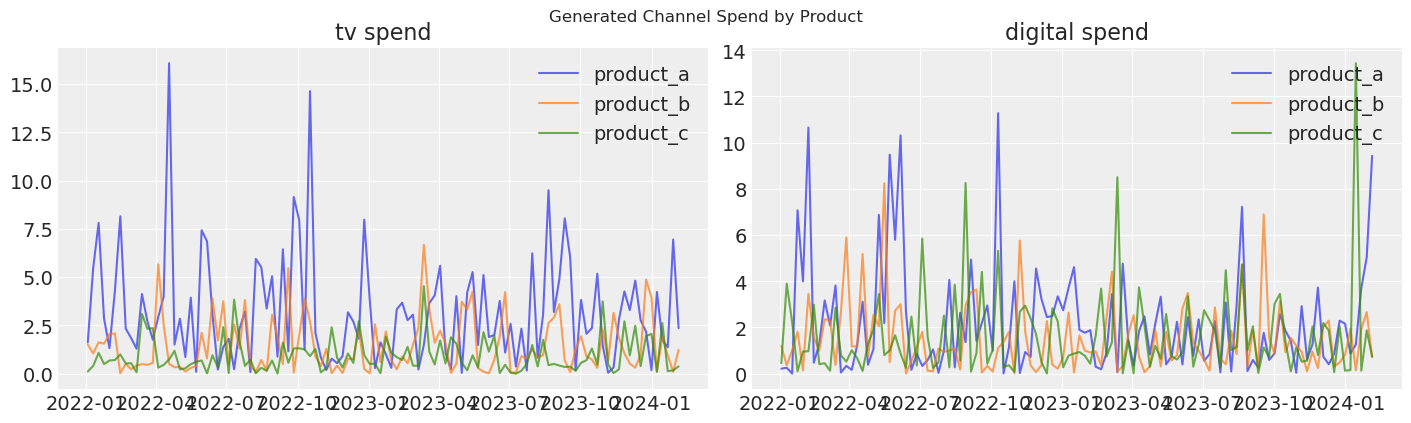

In [33]:
fig, axes = plt.subplots(1, N_CHANNELS, figsize=(14, 4), sharey=False)
for ax, channel in zip(axes, CHANNELS, strict=True):
    for product in PRODUCTS:
        mask = spend_df["product"] == product
        ax.plot(
            spend_df.loc[mask, "date"],
            spend_df.loc[mask, channel],
            label=product,
            alpha=0.7,
        )
    ax.set_title(f"{channel} spend")
    ax.legend()
fig.suptitle("Generated Channel Spend by Product", y=1.02)

### 2.2 Draw Ground-Truth Parameters

In [ ]:
intercept_true = pm.draw(
    pm.Normal.dist(mu=5, sigma=1), draws=N_PRODUCTS, random_seed=rng
)

adstock_alpha_true = pm.draw(
    pm.Beta.dist(alpha=1, beta=3), draws=N_PRODUCTS * N_CHANNELS, random_seed=rng
).reshape(N_PRODUCTS, N_CHANNELS)

saturation_lam_true = pm.draw(
    pm.Gamma.dist(alpha=2, beta=1), draws=N_PRODUCTS * N_CHANNELS, random_seed=rng
).reshape(N_PRODUCTS, N_CHANNELS)

saturation_beta_true = pm.draw(
    pm.HalfNormal.dist(sigma=1), draws=N_PRODUCTS * N_CHANNELS, random_seed=rng
).reshape(N_PRODUCTS, N_CHANNELS)

# Halo coefficients: flagship has 0 self-halo, product_b gets 80%, product_c gets 50%
delta_true = np.array([0.0, 0.8, 0.5])

sigma_true = pm.draw(pm.HalfNormal.dist(sigma=0.5), draws=N_PRODUCTS, random_seed=rng)

print("intercept_true:", intercept_true)
print("adstock_alpha_true:\n", adstock_alpha_true)
print("saturation_lam_true:\n", saturation_lam_true)
print("saturation_beta_true:\n", saturation_beta_true)
print("delta_true:", delta_true)
print("sigma_true:", sigma_true)

### 2.3 Build the DGP Model and Forward-Sample

The DGP matches **Approach 3** (flagship halo):

$$
y_{t,i} = \alpha_i + C_{t,i}
  + \delta_i\, C_{t,\text{flagship}}
  + \varepsilon_{t,i}
$$

In [ ]:
# Pivot spend data to wide-by-product arrays: shape (n_dates, n_products, n_channels)
channel_spend_3d = np.zeros((N_DATES, N_PRODUCTS, N_CHANNELS))
for ip, product in enumerate(PRODUCTS):
    mask = spend_df["product"] == product
    for ic, channel in enumerate(CHANNELS):
        channel_spend_3d[:, ip, ic] = spend_df.loc[mask, channel].values

dgp_coords = {
    "date": DATE_RANGE,
    "product": PRODUCTS,
    "channel": CHANNELS,
}

with pm.Model(coords=dgp_coords) as dgp_model:
    channel_data = pmd.Data(
        "channel_data", channel_spend_3d, dims=("date", "product", "channel")
    )

    y_dummy = pmd.Data(
        "y_dummy",
        np.ones((N_DATES, N_PRODUCTS)),
        dims=("date", "product"),
    )

    alpha_ad = pmd.Beta("alpha_ad", alpha=1, beta=3, dims=("product", "channel"))
    adstocked = geometric_adstock(
        channel_data, alpha=alpha_ad, l_max=L_MAX, dim="date", normalize=True
    )

    lam = pmd.Gamma("lam", alpha=2, beta=1, dims=("product", "channel"))
    beta_ch = pmd.HalfNormal("beta_ch", sigma=1, dims=("product", "channel"))
    channel_contribution = pmd.Deterministic(
        "channel_contribution",
        (beta_ch * logistic_saturation(adstocked, lam)).transpose("date", ...),
    )

    total = pmd.Deterministic(
        "total_contribution",
        channel_contribution.sum(dim="channel"),
    )

    flagship_total = total.isel(product=FLAGSHIP_IDX)

    delta = pmd.HalfNormal("delta", sigma=1, dims="product")
    halo_contribution = pmd.Deterministic(
        "halo_contribution", (delta * flagship_total).transpose("date", ...)
    )

    intercept = pmd.Normal("intercept", mu=5, sigma=1, dims="product")

    mu = intercept + total + halo_contribution
    mu = mu.transpose("date", "product")

    sigma = pmd.HalfNormal("sigma", sigma=0.5, dims="product")
    pmd.Normal("y", mu=mu, sigma=sigma, observed=y_dummy, dims=("date", "product"))

In [ ]:
dgp_model_do = do(
    dgp_model,
    {
        "intercept": intercept_true,
        "alpha_ad": adstock_alpha_true,
        "lam": saturation_lam_true,
        "beta_ch": saturation_beta_true,
        "delta": delta_true,
        "sigma": sigma_true,
    },
)

with dgp_model_do:
    idata_dgp = pm.sample_prior_predictive(draws=1, random_seed=rng)

In [ ]:
# After do(), observed y is in prior_predictive; deterministics are in prior.
y_obs_xr = idata_dgp["prior_predictive"]["y"].sel(chain=0, draw=0)
y_obs = y_obs_xr.values  # (n_dates, n_products)

halo_true_xr = idata_dgp["prior"]["halo_contribution"].sel(chain=0, draw=0)
total_true_xr = idata_dgp["prior"]["total_contribution"].sel(chain=0, draw=0)

# Trim the first L_MAX rows (adstock burn-in)
trim = L_MAX
date_range_trimmed = DATE_RANGE[trim:]
y_obs_trimmed = y_obs[trim:]
channel_spend_trimmed = channel_spend_3d[trim:]
halo_true_trimmed = halo_true_xr.values[trim:]
total_true_trimmed = total_true_xr.values[trim:]

n_dates_trimmed = len(date_range_trimmed)

# Build the long-format DataFrame for the MMM class
rows_final = []
for ip, product in enumerate(PRODUCTS):
    for it, date in enumerate(date_range_trimmed):
        row = {"date": date, "product": product}
        for ic, channel in enumerate(CHANNELS):
            row[channel] = channel_spend_trimmed[it, ip, ic]
        row["y"] = y_obs_trimmed[it, ip]
        rows_final.append(row)

data_df = pd.DataFrame(rows_final)
data_df.head(9)

In [ ]:
fig, axes = plt.subplots(N_PRODUCTS, 1, figsize=(12, 3 * N_PRODUCTS), sharex=True)
for ip, product in enumerate(PRODUCTS):
    ax = axes[ip]
    mask = data_df["product"] == product
    ax.plot(data_df.loc[mask, "date"], data_df.loc[mask, "y"], label="y (observed)")
    ax.plot(
        date_range_trimmed,
        halo_true_trimmed[:, ip],
        label="halo contribution (ground truth)",
        linestyle="--",
        alpha=0.8,
    )
    ax.set_title(product)
    ax.legend(loc="upper right")
fig.suptitle("Synthetic Target with Ground-Truth Halo Contributions", y=1.01)
fig.tight_layout()

---
## 3. Baseline — Standard Multi-Dimensional MMM (No Halo)

We fit the standard `MMM` class with `dims=("product",)`.  This model has no
mechanism for cross-product spillover; any halo-driven sales will be absorbed
into the intercept or direct channel contributions.

In [ ]:
X_baseline = data_df.drop(columns=["y"])
y_baseline = data_df["y"]

mmm_baseline = MMM(
    date_column="date",
    channel_columns=CHANNELS,
    target_column="y",
    adstock=GeometricAdstock(l_max=L_MAX),
    saturation=LogisticSaturation(),
    dims=("product",),
)

mmm_baseline.build_model(X_baseline, y_baseline)

In [ ]:
mmm_baseline.fit(X=X_baseline, y=y_baseline, **SAMPLER_CONFIG)

In [ ]:
mmm_baseline.sample_posterior_predictive(X=X_baseline, random_seed=RANDOM_SEED)

In [ ]:
fig, axes = mmm_baseline.plot.posterior_predictive(var=["y"], hdi_prob=0.94)
fig.suptitle("Baseline MMM — Posterior Predictive", y=1.02)

---
## 4. Approach 0 — Other Products' Total Media as a Channel

For each product, compute the total media spend from all *other* products and
pass it as an additional entry in `channel_columns`.  The `MMM` class then
applies adstock and saturation to this cross-product signal automatically.

In [ ]:
data_df["total_spend"] = data_df[CHANNELS].sum(axis=1)
date_total_spend = data_df.groupby("date")["total_spend"].transform("sum")
data_df["other_products_total_media"] = date_total_spend - data_df["total_spend"]

In [ ]:
X_approach0 = data_df.drop(columns=["y", "total_spend"])
y_approach0 = data_df["y"]

mmm_approach0 = MMM(
    date_column="date",
    channel_columns=[*CHANNELS, "other_products_total_media"],
    target_column="y",
    adstock=GeometricAdstock(l_max=L_MAX),
    saturation=LogisticSaturation(),
    dims=("product",),
)

mmm_approach0.build_model(X_approach0, y_approach0)

In [ ]:
mmm_approach0.fit(X=X_approach0, y=y_approach0, **SAMPLER_CONFIG)

In [ ]:
mmm_approach0.sample_posterior_predictive(X=X_approach0, random_seed=RANDOM_SEED)

In [ ]:
fig, axes = mmm_approach0.plot.posterior_predictive(var=["y"], hdi_prob=0.94)
fig.suptitle(
    "Approach 0 — Other Products' Total Media as Channel (Posterior Predictive)",
    y=1.02,
)

---
## 5. Halo `MuEffect` Definitions

The `MMM` class supports an extensibility mechanism called **`MuEffect`**
(defined in `pymc_marketing.mmm.additive_effect`).  Any object that implements
the three-method protocol -- `create_data`, `create_effect`, `set_data` -- can
be appended to `mmm.mu_effects` before `build_model`.  During model
construction the effect's `create_effect` is called **after**
`channel_contribution` has been registered as a `pmd.Deterministic`, so a
`MuEffect` can access `mmm.model["channel_contribution"]` to derive halo
terms from the already-adstocked/saturated channel contributions.

Below we define three `MuEffect` subclasses -- one for each halo approach.

In [ ]:
class SpilloverMatrixEffect(MuEffect):
    """Approach 1 -- Full spillover matrix as a MuEffect."""

    sigma_H: float = 0.3
    product_dim: str = "product"

    def create_data(self, mmm):
        """Register the product_source coordinate."""
        mmm.model.add_coord("product_source", mmm.model.coords[self.product_dim])

    def create_effect(self, mmm):
        """Add spillover: sum_j H_ij * C_{t,j}."""
        total = mmm.model["channel_contribution"].sum(dim="channel")
        total_source = total.rename({self.product_dim: "product_source"})
        H = pmd.HalfNormal(
            "H",
            sigma=self.sigma_H,
            dims=(self.product_dim, "product_source"),
        )
        return pmd.Deterministic(
            "halo_contribution",
            (H * total_source).sum(dim="product_source").transpose("date", ...),
        )

    def set_data(self, mmm, model, X):
        """No-op: halo recomputes from updated channel data."""


class BrandAwarenessEffect(MuEffect):
    """Approach 2 -- Latent brand awareness factor as a MuEffect."""

    sigma_lam: float = 0.5
    product_dim: str = "product"

    def create_data(self, mmm):
        """No extra data needed; derives from channel_contribution."""

    def create_effect(self, mmm):
        """Add latent brand awareness: lam_i * sum_j w_j * C_{t,j}."""
        total = mmm.model["channel_contribution"].sum(dim="channel")
        w_raw = pmd.HalfNormal("w_raw", sigma=1.0, dims=self.product_dim)
        w = pmd.Deterministic("w", w_raw / w_raw.sum(dim=self.product_dim))
        awareness = pmd.Deterministic(
            "brand_awareness",
            (w * total).sum(dim=self.product_dim),
        )
        lam_halo = pmd.HalfNormal(
            "lam_halo",
            sigma=self.sigma_lam,
            dims=self.product_dim,
        )
        return pmd.Deterministic(
            "halo_contribution",
            (lam_halo * awareness).transpose("date", ...),
        )

    def set_data(self, mmm, model, X):
        """No-op: halo recomputes from updated channel data."""


class FlagshipHaloEffect(MuEffect):
    """Approach 3 -- Flagship-specific halo as a MuEffect."""

    flagship_idx: int = 0
    sigma_delta: float = 0.5

    def create_data(self, mmm):
        """No extra data needed; derives from channel_contribution."""

    def create_effect(self, mmm):
        """Add flagship halo: delta_i * C_{t, flagship}."""
        total = mmm.model["channel_contribution"].sum(dim="channel")
        flagship_total = total.isel(product=self.flagship_idx)
        delta = pmd.HalfNormal("delta", sigma=self.sigma_delta, dims=mmm.dims)
        return pmd.Deterministic(
            "halo_contribution",
            (delta * flagship_total).transpose("date", ...),
        )

    def set_data(self, mmm, model, X):
        """No-op: halo recomputes from updated channel data."""

---
## 6. Approach 1 — Spillover Matrix

$$
y_{t,i} = \alpha_i + C_{t,i}
  + \sum_{j=1}^{P} H_{ij}\, C_{t,j}
  + \varepsilon_{t,i}
$$

We use the `MMM` class with a `SpilloverMatrixEffect` appended to
`mu_effects`.

In [ ]:
X_halo = data_df[["date", "product", *CHANNELS]]
y_halo = data_df["y"]

mmm_approach1 = MMM(
    date_column="date",
    channel_columns=CHANNELS,
    target_column="y",
    adstock=GeometricAdstock(l_max=L_MAX),
    saturation=LogisticSaturation(),
    dims=("product",),
)
mmm_approach1.mu_effects.append(SpilloverMatrixEffect())
mmm_approach1.fit(X=X_halo, y=y_halo, **SAMPLER_CONFIG)
mmm_approach1.sample_posterior_predictive(X=X_halo, random_seed=RANDOM_SEED)

In [ ]:
az.plot_posterior(mmm_approach1.idata, var_names=["H"], figsize=(16, 8))
plt.suptitle("Approach 1 — Spillover Matrix H (posterior)", y=1.02)
plt.tight_layout()

---
## 7. Approach 2 — Latent Brand Awareness Factor

$$
A_t = \sum_j w_j\, C_{t,j},
\qquad
y_{t,i} = \alpha_i + C_{t,i} + \lambda_i\, A_t + \varepsilon_{t,i}
$$

In [ ]:
mmm_approach2 = MMM(
    date_column="date",
    channel_columns=CHANNELS,
    target_column="y",
    adstock=GeometricAdstock(l_max=L_MAX),
    saturation=LogisticSaturation(),
    dims=("product",),
)
mmm_approach2.mu_effects.append(BrandAwarenessEffect())
mmm_approach2.fit(X=X_halo, y=y_halo, **SAMPLER_CONFIG)
mmm_approach2.sample_posterior_predictive(X=X_halo, random_seed=RANDOM_SEED)

In [ ]:
axes = az.plot_posterior(
    mmm_approach2.idata, var_names=["w", "lam_halo"], figsize=(14, 6)
)
plt.suptitle("Approach 2 — Brand Awareness Weights & Sensitivities", y=1.05)
plt.tight_layout()

---
## 8. Approach 3 — Flagship-Specific Halo

$$
y_{t,i} = \alpha_i + C_{t,i}
  + \delta_i\, C_{t,\text{flagship}}
  + \varepsilon_{t,i}
$$

This matches the DGP exactly, so it should recover the ground truth
$\delta = [0.0, 0.8, 0.5]$ most accurately.

In [ ]:
mmm_approach3 = MMM(
    date_column="date",
    channel_columns=CHANNELS,
    target_column="y",
    adstock=GeometricAdstock(l_max=L_MAX),
    saturation=LogisticSaturation(),
    dims=("product",),
)
mmm_approach3.mu_effects.append(
    FlagshipHaloEffect(flagship_idx=FLAGSHIP_IDX, sigma_delta=0.5)
)
mmm_approach3.fit(X=X_halo, y=y_halo, **SAMPLER_CONFIG)
mmm_approach3.sample_posterior_predictive(X=X_halo, random_seed=RANDOM_SEED)

In [ ]:
az.plot_posterior(
    mmm_approach3.idata,
    var_names=["delta"],
    ref_val={"delta": [{"ref_val": v} for v in delta_true]},
    figsize=(14, 4),
)
plt.suptitle("Approach 3 — Flagship Halo \u03b4 (posterior vs. ground truth)", y=1.05)
plt.tight_layout()

---
## 9. Results Comparison

### 9.1 Posterior Predictive Comparison

In [ ]:
mmm_models = [mmm_approach0, mmm_approach1, mmm_approach2, mmm_approach3]
model_labels = [
    "Approach 0 (Other Spend Channel)",
    "Approach 1 (Spillover Matrix)",
    "Approach 2 (Brand Awareness)",
    "Approach 3 (Flagship Halo)",
]
colors = ["C3", "C0", "C1", "C2"]

y_target = np.zeros((n_dates_trimmed, N_PRODUCTS))
for ip, product in enumerate(PRODUCTS):
    mask = data_df["product"] == product
    y_target[:, ip] = data_df.loc[mask, "y"].values

pp_np_arrays = []
for mmm_obj in mmm_models:
    pp_scaled = mmm_obj.idata.posterior_predictive["y"].values
    target_scale = mmm_obj.idata.constant_data["target_scale"].values
    pp_np_arrays.append(pp_scaled * target_scale)

fig, axes = plt.subplots(N_PRODUCTS, 1, figsize=(14, 3.5 * N_PRODUCTS), sharex=True)

for ip, product in enumerate(PRODUCTS):
    ax = axes[ip]
    ax.plot(
        date_range_trimmed, y_target[:, ip], "k-", lw=1.5, label="observed", zorder=5
    )

    for label, pp_np, color in zip(model_labels, pp_np_arrays, colors, strict=True):
        pp_mean = pp_np.mean(axis=(0, 1))[:, ip]
        pp_low = np.quantile(pp_np, 0.03, axis=(0, 1))[:, ip]
        pp_high = np.quantile(pp_np, 0.97, axis=(0, 1))[:, ip]
        ax.plot(date_range_trimmed, pp_mean, color=color, alpha=0.8, label=label)
        ax.fill_between(
            date_range_trimmed,
            pp_low,
            pp_high,
            color=color,
            alpha=0.15,
        )

    ax.set_title(product)
    ax.legend(loc="upper right", fontsize=8)

fig.suptitle("Posterior Predictive Comparison (Halo Models)", y=1.01)
fig.tight_layout()

### 9.2 Halo Parameter Recovery

The DGP used $\delta = [0.0, 0.8, 0.5]$.  We compare what each approach
recovered.

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# --- Approach 0: channel contribution for other_products_total_media
ax = axes[0]
beta_sat = mmm_approach0.idata.posterior["saturation_beta"]
for _ip, product in enumerate(PRODUCTS):
    vals = beta_sat.sel(
        product=product, channel="other_products_total_media"
    ).values.flatten()
    ax.hist(vals, bins=40, alpha=0.5, label=product, density=True)
ax.set_title("Approach 0: saturation_beta (other media)")
ax.set_xlabel("channel coefficient")
ax.legend()

# --- Approach 1: Spillover matrix H — extract the flagship column (column 0)
ax = axes[1]
H_post = mmm_approach1.idata.posterior["H"]
H_from_flagship = H_post.sel(product_source=PRODUCTS[FLAGSHIP_IDX])
for ip, product in enumerate(PRODUCTS):
    vals = H_from_flagship.sel(product=product).values.flatten()
    ax.hist(vals, bins=40, alpha=0.5, label=product, density=True)
    ax.axvline(delta_true[ip], color=f"C{ip}", linestyle="--", lw=2)
ax.set_title("Approach 1: H[:, flagship]")
ax.set_xlabel("spillover coefficient")
ax.legend()

# --- Approach 2: lambda_i * w_flagship
ax = axes[2]
w_post = mmm_approach2.idata.posterior["w"]
lam_post = mmm_approach2.idata.posterior["lam_halo"]
w_flagship = w_post.sel(product=PRODUCTS[FLAGSHIP_IDX])
for ip, product in enumerate(PRODUCTS):
    effective = (lam_post.sel(product=product) * w_flagship).values.flatten()
    ax.hist(effective, bins=40, alpha=0.5, label=product, density=True)
    ax.axvline(delta_true[ip], color=f"C{ip}", linestyle="--", lw=2)
ax.set_title("Approach 2: \u03bbᵢ \u00b7 w_flagship")
ax.set_xlabel("effective halo coefficient")
ax.legend()

# --- Approach 3: delta directly
ax = axes[3]
delta_post = mmm_approach3.idata.posterior["delta"]
for ip, product in enumerate(PRODUCTS):
    vals = delta_post.sel(product=product).values.flatten()
    ax.hist(vals, bins=40, alpha=0.5, label=product, density=True)
    ax.axvline(delta_true[ip], color=f"C{ip}", linestyle="--", lw=2)
ax.set_title("Approach 3: \u03b4\u1d62 (direct)")
ax.set_xlabel("halo coefficient \u03b4")
ax.legend()

fig.suptitle("Halo Parameter Recovery (dashed = ground truth)", y=1.02, fontsize=14)
fig.tight_layout()

### 9.3 Summary Table

In [ ]:
summary_rows = []
for label, pp_np in zip(model_labels, pp_np_arrays, strict=True):
    residuals = pp_np.mean(axis=(0, 1)) - y_target
    rmse = np.sqrt((residuals**2).mean())
    summary_rows.append({"Model": label, "RMSE (in-sample)": round(rmse, 4)})

summary_table = pd.DataFrame(summary_rows)
print(summary_table.to_string(index=False))

### 9.4 Discussion

All four halo-aware models are now implemented using the `MMM` class, gaining
full access to `sample_posterior_predictive`, budget optimisation,
serialisation, and the standard channel contribution machinery.

- **Approach 0 (Other Products' Total Media)** treats the aggregate spend of
  other products as an additional channel, applying adstock and saturation
  automatically.  This is the simplest proxy but cannot distinguish *which*
  product drives the halo.
- **Approach 3 (Flagship Halo)** matches the DGP and should recover the true
  $\delta$ values most accurately.  The posterior for `delta[product_a]` should
  concentrate near 0, confirming no self-halo.
- **Approach 1 (Spillover Matrix)** is more flexible but has $P^2$ parameters.
  The diagonal and off-diagonal elements of $H$ compete for variance, making
  identification harder.
- **Approach 2 (Brand Awareness)** captures the qualitative halo pattern but
  is a rank-1 approximation -- the product $\lambda_i \cdot w_j$ may not
  perfectly recover the true $\delta$ structure.
- **The Baseline MMM** (not shown in the halo comparison plots) absorbs the
  halo effect into the intercept and direct channel contributions, leading to
  inflated ROAS estimates for non-flagship products and deflated estimates for
  the flagship.